# Satellite Dataset Generation #

## Import Files & APIs ##

Note: Since the raw data is around 9 GB total, the raw data is stored on my (James's) local machine. If the raw data needs to be accessed, contact me by phone or email.

Additionally, the range of the dataset is from 2017-01-01 to 2022-09-23. There were some issues with downloading the data, so the data past 2022-09-23 could not be accessed.

Data was obtained from https://podaac.jpl.nasa.gov/dataset/CYGNSS_L3_SOIL_MOISTURE_V1.0#

In [1]:
from glob import glob
from xarray import open_mfdataset
from warnings import filterwarnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
import math
import os
import sys

import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
filterwarnings('ignore')

In [2]:
sat_data = "./complete_satellite_data/ucar*.nc4"
sat_data_f = sorted(glob(sat_data)) # finds files recursively

sat_ds = open_mfdataset(sat_data_f, combine="by_coords")
sat_ds

<xarray.Dataset> Size: 20GB
Dimensions:         (time: 2091, timeslices: 4, lat: 252, lon: 802, startstop: 2)
Coordinates:
  * time            (time) datetime64[ns] 17kB 2017-03-18T12:00:00 ... 2022-1...
Dimensions without coordinates: timeslices, lat, lon, startstop
Data variables:
    SM_subdaily     (time, timeslices, lat, lon) float32 7GB dask.array<chunksize=(1, 4, 252, 802), meta=np.ndarray>
    SIGMA_subdaily  (time, timeslices, lat, lon) float32 7GB dask.array<chunksize=(1, 4, 252, 802), meta=np.ndarray>
    longitude       (time, lat, lon) float32 2GB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    latitude        (time, lat, lon) float32 2GB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    timeintervals   (time, startstop, timeslices) timedelta64[ns] 134kB dask.array<chunksize=(1, 2, 4), meta=np.ndarray>
    SM_daily        (time, lat, lon) float32 2GB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    SIGMA_daily     (time, lat, lon) float32 2GB dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
Attributes: (12/46)
    source:                              ucar_cu_cygnss_sm_v1_2017_077.nc
    id:                                  PODAAC-CYGNU-L3SM1
    ShortName:                           CYGNSS_L3_SOIL_MOISTURE_V1.0
    title:                               CYGNSS Level 3 Soil Moisture from UC...
    summary:                             The CYGNSS Level 3 Soil Moisture Pro...
    comment:                             Dataset created by UCAR and CU Boulder
    ...                                  ...
    build_dmrpp_metadata.build_dmrpp:    3.20.9-91
    build_dmrpp_metadata.bes:            3.20.9-91
    build_dmrpp_metadata.libdap:         libdap-3.20.8-41
    build_dmrpp_metadata.configuration:  \n# TheBESKeys::get_as_config()\nAll...
    build_dmrpp_metadata.invocation:     build_dmrpp -c /tmp/conf_oWLD -f /tm...
    history_json:                        [{"$schema":"https:\/\/harmony.earth...

## Distance to stations ##

In [3]:
latitudes = sat_ds['latitude'].values
longitudes = sat_ds['longitude'].values

lat_list = [float(item[0]) for item in latitudes[0]]
lon_list = [float(item) for item in longitudes[0][0]]

In [4]:
# Haversine formula to calculate distance
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Difference in coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    # Earth's radius in kilometers (can be adjusted for different units)
    R = 6371.0
    distance = R * c

    return distance

In [5]:
def find_closest_coords(stat_lats, stat_lons, lat_list, lon_list):
    assert len(stat_lats) == len(stat_lons)
    
    closest_coord_idx = []
    closest_coord = []
    for i in range(len(stat_lats)):
        stat_lat = stat_lats[i]
        stat_lon = stat_lons[i]
        
        lat_idx = min(
            range(len(lat_list)), 
            key=lambda j: abs(lat_list[j] - stat_lat)
        )
        lon_idx = min(
            range(len(lon_list)), 
            key=lambda j: abs(lon_list[j] - stat_lon)
        )
        
        closest_coord_idx.append((lat_idx, lon_idx))
        closest_coord.append((lat_list[lat_idx], lon_list[lon_idx]))
    
    return closest_coord_idx, closest_coord

In [6]:
# Make dataframe from station data
def make_stat_dist_df(closets_coord_function):
    stat_ids = ['5', '1', '6', '4', '2', '3']
    stations_data = [
        {'stat_lat': 30.3989, 'stat_lon': -98.6105},
        {'stat_lat': 30.4193, 'stat_lon': -98.8046},
        {'stat_lat': 30.4421, 'stat_lon': -98.8427},
        {'stat_lat': 30.4600, 'stat_lon': -98.9407},
        {'stat_lat': 30.2454, 'stat_lon': -98.7059},
        {'stat_lat': 30.2758, 'stat_lon': -98.7242}
    ]
    stat_df = pd.DataFrame(stations_data, index=stat_ids)
    stat_df.index.name = 'stat_id'
    
    stat_lats = list(stat_df['stat_lat'])
    stat_lons = list(stat_df['stat_lon'])
    
    closest_coord_idx, closest_coord = closets_coord_function(stat_lats, stat_lons, lat_list, lon_list)
    stat_df['closest_lat'] = [round(item[0], 4) for item in closest_coord]
    stat_df['closest_lon'] = [round(item[1], 4) for item in closest_coord]
    stat_df['closest_idx'] = closest_coord_idx
    
    stat_df['distance'] = stat_df.apply(
        lambda row: haversine(
            row['stat_lat'], 
            row['stat_lon'], 
            row['closest_lat'], 
            row['closest_lon']), 
        axis=1, 
        result_type='expand'
    )
    
    return stat_df

In [7]:
# Dataframe displays each station's coordinates, the closest available coordinates from the satellite
# data, the closest coordinates' corresponding indices, and the distance between the station and closest 
# available coordinate.
stat_df = make_stat_dist_df(find_closest_coords)
stat_df

,stat_lat,stat_lon,closest_lat,closest_lon,closest_idx,distance
stat_id,,,,,,
5,30.3989,-98.6105,30.3118,-98.7759,"(228, 97)",18.592113
1,30.4193,-98.8046,30.3118,-98.7759,"(228, 97)",12.266494
6,30.4421,-98.8427,30.3118,-98.7759,"(228, 97)",15.842545
4,30.4600,-98.9407,30.3118,-98.7759,"(228, 97)",22.835190
2,30.2454,-98.7059,30.3118,-98.7759,"(228, 97)",9.984826
3,30.2758,-98.7242,30.3118,-98.7759,"(228, 97)",6.376777


## Check if coordinates are correct ##

In [8]:
global_sm = sat_ds['SM_daily'].values

In [9]:
def draw_map(stat_df, day_idx=1):
    # Create map
    fig = plt.figure(figsize=(8, 6), edgecolor='w')

    m = Basemap(width=5000000,height=3500000,
                resolution='l',projection='cass',\
                llcrnrlon=-99.5,llcrnrlat=29.75,urcrnrlon=-98,urcrnrlat=31,\
                lat_ts=0,lat_0=30.267153,lon_0=-97.743057) 
    xi, yi = longitudes[day_idx,217:247,80:110], latitudes[day_idx,217:247,80:110]
    cs = m.pcolor(xi, yi, global_sm[day_idx,217:247,80:110], latlon = True)

    m.drawcoastlines()
    m.drawstates()
    m.drawcountries()

    # Plot points
    colors = ['b', 'g', 'y', 'c', 'w', 'm']
    for index, row in stat_df.iterrows():
        stat_id = int(index)
        stat_lon, stat_lat = row['stat_lon'], row['stat_lat']
        closest_lon, closest_lat = row['closest_lon'], row['closest_lat']

        stat_xpt, stat_ypt = m(stat_lon,stat_lat)
        m.plot(stat_xpt, stat_ypt, colors[stat_id - 1] + 'o')
        plt.text(
            stat_xpt+1000,
            stat_ypt+1000,
            'Station %d' % (int(index)), 
            c=colors[stat_id - 1]
        )

        closest_xpt, closest_ypt = m(closest_lon,closest_lat)
        m.plot(closest_xpt, closest_ypt, colors[stat_id - 1] + 'o')
        plt.text(
            closest_xpt+1000,
            closest_ypt+1000,
            'Closest to Station %d' % (stat_id), 
            c=colors[stat_id - 1]
        )

    opt_lon, opt_lat = -98.7759, 30.3118
    opt_xpt, opt_ypt = m(opt_lon, opt_lat)
    m.plot(opt_xpt, opt_ypt, 'ro')
    plt.text(
        opt_xpt+1000,
        opt_ypt+1000,
        'Optimal point', 
        c='r'
    )


    cbar = m.colorbar(cs, location='bottom', pad="10%")
    cbar.set_label('$cm^3 cm^{-3}$')

    plt.title('Soil Moisture CyGNSS')
    plt.show()

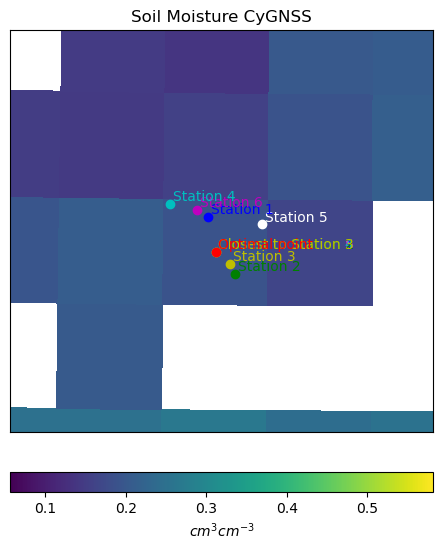

In [10]:
draw_map(stat_df)

## Generate soil moisture dataframes for each station ##

In [11]:
# Get dates for indexing pandas dataframe
index_dates = []
unavail_dates = []
for file in sat_data_f:
    year = int(file[-16:-12])
    day = int(file[-11:-8])
    
    new_date = datetime.datetime(year, 1, 1) + datetime.timedelta(day - 1)
    if len(index_dates) > 0 and (new_date - index_dates[-1]) != datetime.timedelta(days=1):
        no_date = index_dates[-1] +  datetime.timedelta(days=1)
        unavail_dates.append(no_date)
        index_dates.append(no_date)
    
    index_dates.append(new_date)
index_dates = np.array(index_dates)

In [12]:
# Obtain the soil moisture levels for the given station
def sm_lvl_list(stat_id):
    lat, lon = stat_df.loc[stat_id]['closest_idx']
    l3_sm = []
    i = 0
    for date in index_dates:
        if date in unavail_dates:
            l3_sm.append(np.nan)
        else:
            l3_sm.append(global_sm[i][lat][lon])
            i += 1
    return np.array(l3_sm)

In [13]:
# Generate soil moisture dataframe that also includes distance data
def create_sm_df(stat_id):
    sm_df = pd.DataFrame(index=index_dates)
    sm_df.index.name = "Date"

    sm_data = sm_lvl_list(stat_id)
    dist_data = [None if np.isnan(sm) else stat_df.loc[stat_id]['distance'] for sm in sm_data]

    sm_df['soil_moisture'] = sm_data
    sm_df['distance'] = dist_data

    return sm_df

In [14]:
# Convert soil moisture dataframes into CSV files
sm_df_list = []
for i in range(1, 7):
    stat_id = str(i)
    
    file_name = "Station" + stat_id + "_Satellite.csv"
    target_file = os.path.join("./satellite_data_csv", file_name)
    f = open(target_file, "w")
    
    sm_df = create_sm_df(stat_id)
    sm_df.to_csv(f)
    
    f.close()
    
    sm_df_list.append(sm_df)

In [15]:
# Code generated from ChatGPT
def are_dates_contiguous(date_list):
    if not date_list:
        return False  # Empty list is not contiguous
    
    # Sort the list to ensure dates are in ascending order
    sorted_dates = sorted(date_list)
    
    # Check if the difference between consecutive dates is exactly one day
    for i in range(len(sorted_dates) - 1):
        if (sorted_dates[i + 1] - sorted_dates[i]) != datetime.timedelta(days=1):
            print(sorted_dates[i + 1])
            print(sorted_dates[i])
            return False
    return True

In [16]:
are_dates_contiguous(index_dates.tolist())

True

In [17]:
sm_df_list[0]

,soil_moisture,distance
Date,,
2017-03-18,NaN,NaN
2017-03-19,0.191104,12.266494
2017-03-20,0.210310,12.266494
2017-03-21,0.168200,12.266494
2017-03-22,NaN,NaN
...,...,...
2022-12-06,0.158229,12.266494
2022-12-07,0.161177,12.266494
2022-12-08,NaN,NaN


## Clean up missing data ##

For the data points that are missing, the method that is going to be used here is to take the soil moisture of the next closest coordinate that is within a 1 unit radius of the same day that is not NaN. If all of the surrounding units are missing, the missing data will be filled in using forward fill.

In [18]:
sm_df_list[0].isnull().sum()

soil_moisture    320
distance         320
dtype: int64

In [19]:
def close_coord_clean(stat_id, radius):
    sm_df = sm_df_list[int(stat_id) - 1]
    stat_lat, stat_lon = stat_df.loc[stat_id, 'stat_lat'], stat_df.loc[stat_id, 'stat_lon']
    cur_lat, cur_lon = stat_df.loc[stat_id, 'closest_idx']

    new_lat_idx_range = range(cur_lat - radius, cur_lat + radius + 1)
    new_lon_idx_range = range(cur_lon - radius, cur_lon + radius + 1)
    new_coords_idx_list = []
    for lat in new_lat_idx_range:
        for lon in new_lon_idx_range:
            new_coord = (lat, lon)
            if new_coord != (cur_lat, cur_lon):
                new_coords_idx_list.append(new_coord)

    new_sm_df = sm_df.copy()
    i = 0
    for date in index_dates:
        if date not in unavail_dates:
            if np.isnan(new_sm_df.loc[date]['soil_moisture']):
                best_dist = sys.float_info.max
                best_sm = -1
                for coord in new_coords_idx_list:
                    new_lat_idx = coord[0]
                    new_lon_idx = coord[1]
                    new_sm = global_sm[i][new_lat_idx][new_lon_idx]

                    if not np.isnan(new_sm):
                        new_lat = lat_list[new_lat_idx]
                        new_lon = lon_list[new_lon_idx]

                        new_dist = haversine(stat_lat, stat_lon, new_lat, new_lon)

                        best_sm = new_sm if new_dist < best_dist else best_sm
                        best_dist = min(new_dist, best_dist)

                if best_sm > -1:
                    new_sm_df.iat[i, 0] = best_sm
                    new_sm_df.iat[i, 1] = best_dist
            i += 1
            
    return new_sm_df

In [20]:
new_sm_df_1 = close_coord_clean('1', 1)

In [21]:
new_sm_df_1

,soil_moisture,distance
Date,,
2017-03-18,0.228371,61.736882
2017-03-19,0.191104,12.266494
2017-03-20,0.210310,12.266494
2017-03-21,0.168200,12.266494
2017-03-22,0.146193,24.518852
...,...,...
2022-12-06,0.158229,12.266494
2022-12-07,0.151538,24.518852
2022-12-08,NaN,NaN


In [22]:
new_sm_df_1.isnull().sum()

soil_moisture    144
distance         144
dtype: int64

In [23]:
def ffill_clean(sm_df):
    new_sm_df = sm_df.copy()
    new_sm_df['soil_moisture'].fillna(method="ffill", inplace=True)
    new_sm_df['distance'].fillna(method="ffill", inplace=True)
    return new_sm_df

In [24]:
ffil_clean_sm_df_1 = ffill_clean(new_sm_df_1)
ffil_clean_sm_df_1

,soil_moisture,distance
Date,,
2017-03-18,0.228371,61.736882
2017-03-19,0.191104,12.266494
2017-03-20,0.210310,12.266494
2017-03-21,0.168200,12.266494
2017-03-22,0.146193,24.518852
...,...,...
2022-12-06,0.158229,12.266494
2022-12-07,0.151538,24.518852
2022-12-08,0.151538,24.518852


In [25]:
ffil_clean_sm_df_1.isnull().sum()

soil_moisture    0
distance         0
dtype: int64